## DrainEye - классификация дефектов дренажа

**Цель:** обучить базовую модель классификации на датасете `draineye-defects` для классов `corrosion`, `crack`, `no_damage`.

## Установка зависимостей
**Цель:** установить библиотеки, необходимые для загрузки датасета, обучения модели, оценки качества и визуализации результатов.

In [ ]:
!pip install tensorflow==2.19.0 scikit.learn==1.6.1 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 datasets==4.0.0

## Импорты
**Цель:** подключить все необходимые библиотеки для загрузки данных, обучения модели, оценки качества и визуализации.

In [3]:
import os

# Фиксируем hash seed до инициализации Python-зависимых компонентов
os.environ["PYTHONHASHSEED"] = "42"

# Выносим кеш Hugging Face на Google Drive, чтобы не скачивать датасет заново
os.environ["HF_HOME"] = "/content/drive/MyDrive/draineye/cache"

In [ ]:
from datasets import load_dataset

from google.colab import userdata, drive

import random
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import lite

from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Resizing, Lambda, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import History, ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model

sns.set_theme()
%matplotlib inline

print(tf.config.list_physical_devices('GPU'))

## Конфигурация
**Цель:** задать основные параметры эксперимента, которые будут использоваться дальше в ноутбуке.

### Гиперпараметры
**Цель:** определить параметры обучения, размер изображений, название датасета и пути для сохранения артефактов.

In [5]:
SEED=42
BATCH_SIZE=16
EPOCH=12

IMG_SHAPE=(224, 224, 3)

DATASET_NAME="draineye/draineye-defects"
DATASET_VERSION="v1.0"

DRIVE_PATH = "/content/drive/MyDrive/draineye/"

### Монтирование Google Drive
**Цель:** подключить Google Drive для чтения данных и сохранения обученных моделей.

In [ ]:
drive.mount("/content/drive/")

## Загрузка датасета
**Цель:** получить датасет из [Hugging Face Hub](https://huggingface.co/datasets/draineye/draineye-defects) и подготовить его к дальнейшей обработке.

In [7]:
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

dataset = load_dataset(
    DATASET_NAME,
    revision=DATASET_VERSION
  )

dataset

Resolving data files:   0%|          | 0/1050 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1050
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 225
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 225
    })
})

## Подготовка датасета
**Цель:** зафиксировать воспроизводимость и преобразовать исходный датасет в удобный `tf.data.Dataset`.

### Воспроизводимость
**Цель:** зафиксировать генераторы случайности, чтобы результаты обучения были повторяемыми.

In [8]:
def set_global_seed(seed: int) -> None:
  random.seed(seed)
  np.random.seed(seed)
  tf.random.set_seed(seed)

set_global_seed(SEED)

### Преобразование датасета
**Цель:** привести данные к формату `tf.data.Dataset`, изменить размер изображений и включить оптимизации пайплайна.

In [9]:
def make_tf_dataset(hf_dataset, split: str, shuffle: bool) -> tf.data.Dataset:
  return hf_dataset[split].to_tf_dataset(
      columns="image",
      label_cols="label",
      shuffle=shuffle
  ).map(lambda image, label: (tf.image.resize(image, IMG_SHAPE[:2]), label)) \
   .batch(batch_size=BATCH_SIZE) \
   .cache().prefetch(tf.data.AUTOTUNE)

train = make_tf_dataset(dataset, "train", True)
validation = make_tf_dataset(dataset, "validation", False)
test = make_tf_dataset(dataset, "test", False)

## Анализ датасета
**Цель:** посмотреть на структуру классов, баланс выборки и базовые визуальные свойства изображений.

In [10]:
labels = dataset["train"].features["label"].names
labels

['corrosion', 'crack', 'no_damage']

### Проверка баланса классов
**Цель:** убедиться, что классы распределены по сплитам без сильного перекоса.


In [11]:
print("Баланс классов: ", end='\n\t')
for dts in ["train", "validation", "test"]:
  cls, counts = np.unique(dataset[dts]["label"], return_counts=True)
  print(f"{dts}: {dict(zip(labels, counts.tolist()))}", end='\n\t')

Баланс классов: 
	train: {'corrosion': 350, 'crack': 350, 'no_damage': 350}
	validation: {'corrosion': 75, 'crack': 75, 'no_damage': 75}
	test: {'corrosion': 75, 'crack': 75, 'no_damage': 75}
	

Распределение классов оказалось **полностью сбалансированным**: в каждом сплите классы `corrosion`, `crack` и `no_damage` представлены одинаковым количеством изображений.

### Примеры изображений
**Цель:** визуально проверить, как выглядят изображения каждого класса в обучающей выборке.

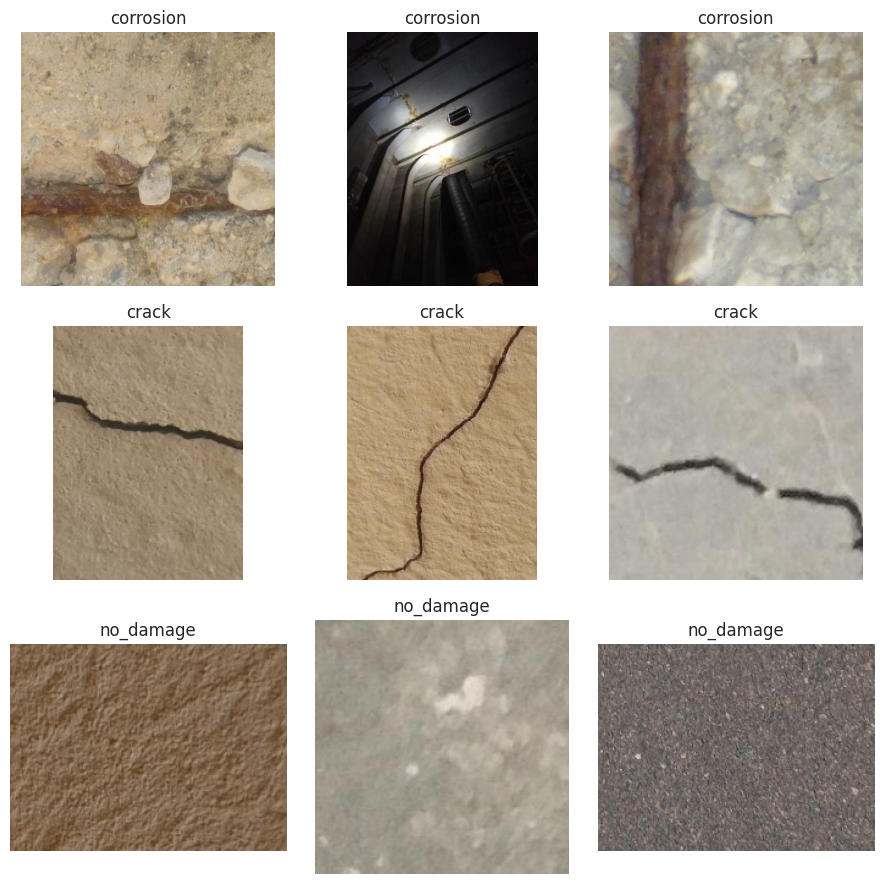

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for (lbl_idx, label) in enumerate(labels):
  imgs = dataset["train"].filter(lambda x: x["label"] == lbl_idx) \
                         .shuffle() \
                         .select(range(3))["image"]

  for (img_idx, img) in enumerate(imgs):
    axes[lbl_idx][img_idx].imshow(img)
    axes[lbl_idx][img_idx].set_title(labels[lbl_idx])
    axes[lbl_idx][img_idx].axis("off")

plt.tight_layout()
plt.show()

### Гистограмма яркости пикселей
**Цель:** оценить распределение яркости на части train-выборки и проверить, нет ли аномалий в данных.

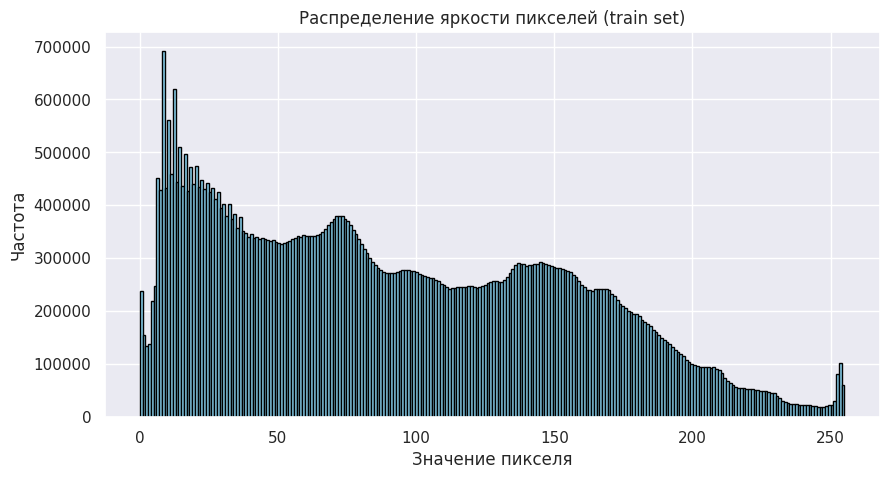

In [ ]:
pixels = np.concatenate([np.array(img).flatten() for img in dataset["train"].shuffle().select(range(100))["image"]])

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(pixels, bins=256, color="skyblue", edgecolor="black")

ax.set_title("Распределение яркости пикселей (train set)")
ax.set_xlabel("Значение пикселя")
ax.set_ylabel("Частота")

plt.show()

Гистограмма показывает, что значения пикселей покрывают почти весь диапазон **0–255**, но основная масса приходится на **низкие и средние значения яркости**. Это означает, что в датасете заметна доля тёмных и умеренно освещённых областей, что похоже на реальные условия съёмки дренажных систем.

При этом распределение не выглядит вырожденным: изображения не сводятся только к очень тёмным или только к пересвеченным кадрам. Небольшие пики на отдельных диапазонах яркости могут быть связаны с повторяющимися текстурами материалов, бликами, тенями или особенностями фона.

## Случайный классификатор
**Цель:** получить baseline-метрику, с которой можно сравнивать качество обучаемой модели.

In [12]:
from sklearn.dummy import DummyClassifier

y_train = np.array(dataset["train"]["label"])
X_train = np.zeros(len(y_train))

y_test = np.array(dataset["test"]["label"])
X_test = np.zeros(len(y_test))

dummy_cls = DummyClassifier(strategy="stratified")
dummy_cls = dummy_cls.fit(X_train, y_train)
score = dummy_cls.score(X_test, y_test)

print(f"Точность случайного классификатора: {score*100:.2f}%")

Точность случайного классификатора: 37.33%


## Обучение модели
**Цель:** построить, скомпилировать и обучить CNN-модель на основе transfer learning.

### Инициализация модели
**Цель:** собрать архитектуру классификатора на базе `MobileNetV2` с замороженной сверточной базой.

In [ ]:
inputs = Input(shape=(None, None, 3))
x = Resizing(*IMG_SHAPE[:2])(inputs)
x = Lambda(preprocess_input)(x)

base = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights="imagenet")

base.trainable = False
x = base(x)

x = GlobalAveragePooling2D()(x)
x = Dropout(rate=0.3)(x)

outputs = Dense(units=3, activation="softmax")(x)

### Сборка модели
**Цель:** объединить входы и выходы в единый объект `keras.Model`.

In [14]:
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Модель построена на базе `MobileNetV2` в режиме transfer learning.  
В качестве backbone используется предобученная сверточная часть с выходом размерности **7 * 7 * 1280**, после чего применяется `GlobalAveragePooling2D`, `Dropout` и финальный полносвязный слой на **3 класса**.

Всего модель содержит ~ **2 млн** параметров, из которых обучаемыми являются только **3,843**. Это означает, что на текущем этапе обучается только классификационная голова, а основная сверточная база остаётся замороженной.

### Загрузка checkpoint
**Цель:** восстановить ранее сохраненную лучшую модель, если checkpoint уже существует.

In [ ]:
checkpoint_file = f"{DRIVE_PATH}/checkpoint.model.keras"

In [ ]:
if os.path.exists(checkpoint_file):
  model = load_model(checkpoint_file, custom_objects={"preprocess_input": preprocess_input})

### Компиляция модели
**Цель:** задать функцию потерь, оптимизатор и метрики для обучения классификатора.

In [ ]:
model.compile(
    optimizer=Adam(),
    # SparseCategoricalCrossentropy подходит, потому что labels хранятся как индексы классов, а не one-hot векторы
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

### Создание callback-ов
**Цель:** сохранять лучшую модель и останавливать обучение, если качество перестает улучшаться.

In [ ]:
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_file,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=4
)

### Обучение модели
**Цель:** обучить модель на train-сплите и валидировать ее на validation-сплите.

In [ ]:
history = model.fit(
    x=train,
    validation_data=validation,
    epochs=EPOCH,
    callbacks=[model_checkpoint, early_stop]
)

Epoch 1/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 901s 13s/step - accuracy: 0.9295 - loss: 0.2084 - val_accuracy: 0.9911 - val_loss: 0.0441
Epoch 2/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9933 - loss: 0.0354 - val_accuracy: 0.9911 - val_loss: 0.0275
Epoch 3/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9962 - loss: 0.0218 - val_accuracy: 0.9911 - val_loss: 0.0232
Epoch 4/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9962 - loss: 0.0142 - val_accuracy: 0.9956 - val_loss: 0.0174
Epoch 5/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9952 - loss: 0.0134 - val_accuracy: 0.9956 - val_loss: 0.0114
Epoch 6/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9990 - loss: 0.0104 - val_accuracy: 0.9956 - val_loss: 0.0139
Epoch 7/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9971 - loss: 0.0102 - val_accuracy: 0.9956 - val_loss: 0.0112
Epoch 8/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9971 - loss: 0.0072 - val_accuracy: 1.0000 - 

### Динамика обучения
**Цель:** проанализировать поведение метрик на train и validation в процессе обучения.

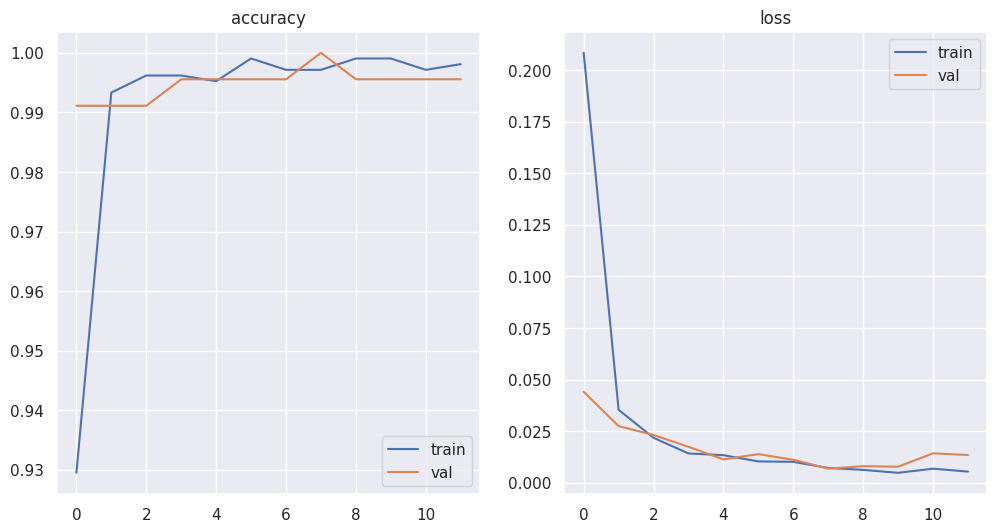

In [ ]:
metrics = [k for k in history.history.keys() if not k.startswith("val_")]

fig, axes = plt.subplots(1, len(metrics), figsize=(12, 6))

for i, metric in enumerate(metrics):
    axes[i].plot(history.history[metric], label="train")
    axes[i].plot(history.history[f"val_{metric}"], label="val")
    axes[i].legend()
    axes[i].set_title(metric)

Во время обучения accuracy на train и validation быстро выросла до значений около **0.99–1.00**, а loss на обоих сплитах стабильно снижался до очень малых значений.

Разрыв между train и validation почти отсутствует, поэтому на этом этапе явных признаков переобучения не наблюдается. При этом настолько высокие метрики выглядят очень сильным результатом, поэтому дальше важно отдельно проверить test-качество и сходство между сплитами.

### Результаты на тестовой выборке
**Цель:** зафиксировать итоговое качество модели на независимом test-сплите.

In [ ]:
model.evaluate(test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0141


[0.014066535048186779, 1.0]

На тестовой выборке модель показала:
- **accuracy ~ 1.00**
- **loss ~ 0.01**

Это означает, что модель корректно классифицировала все объекты test-сплита и сохранила очень низкое значение функции потерь.

### Classification report
**Цель:** посмотреть качество модели по каждому классу отдельно.


In [ ]:
y_pred = np.argmax(model.predict(test), axis=1)
y_true = np.concatenate([y for _, y in test], axis=0)

In [ ]:
print(classification_report(y_true, y_pred, target_names=["corrosion", "crack", "no_damage"]))

              precision    recall  f1-score   support

   corrosion       1.00      1.00      1.00        75
       crack       1.00      1.00      1.00        75
   no_damage       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



Для всех трёх классов (`corrosion`, `crack`, `no_damage`) модель показала:
- **precision ~ 1.00**
- **recall ~ 1.00**
- **f1-score ~ 1.00**

Таким образом, на тестовой выборке качество оказалось идеальным не только по общей accuracy, но и по каждой метрике в разрезе классов.

### Confusion matrix
**Цель:** проанализировать структуру ошибок модели на test-сплите.

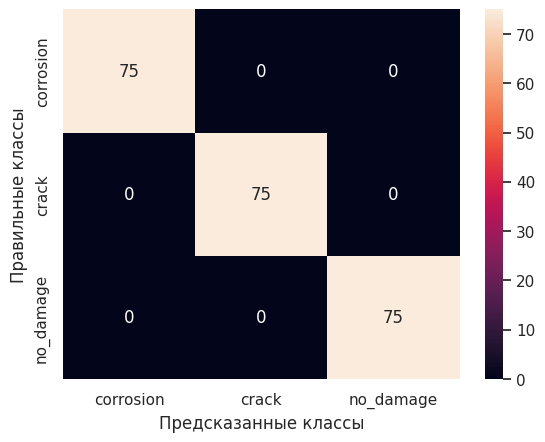

In [ ]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["corrosion", "crack", "no_damage"],
            yticklabels=["corrosion", "crack", "no_damage"])

plt.ylabel("Правильные классы")
plt.xlabel("Предсказанные классы")
plt.show()

Матрица ошибок полностью диагональна:  
модель верно классифицировала все **75** изображений каждого класса и не допустила ни одной ошибки между `corrosion`, `crack` и `no_damage`.

Такой результат подтверждает вывод из classification report: на test-сплите модель не путает классы вообще.

## Анализ сходства train и test
**Цель:** проверить, нет ли между сплитами подозрительно похожих изображений и признаков возможного data leakage.

### Извлечение фичей
**Цель:** получить векторные представления изображений из предпоследнего слоя модели для сравнения по cosine similarity.

In [ ]:
# Делаем срез модели на pooling слое
feature_extractor = Model(inputs=model.input, outputs=model.layers[4].output)

In [ ]:
def get_features(dataset: tf.data.Dataset) -> np.array:
    features = []

    for imgs, labels in dataset:
        features.append(feature_extractor.predict(imgs, verbose=0))

    return np.concatenate(features)

### Проверка сходства
**Цель:** оценить, насколько изображения из test-сплита похожи на train-изображения в пространстве признаков модели.

In [ ]:
train_features = get_features(train)
test_features = get_features(test)

similarity_matrix = cosine_similarity(test_features, train_features)

# Смотрим максимум по каждой строке: для каждого test-образца ищем ближайший объект из train
max_similarity = np.max(similarity_matrix, axis=1)

print(f"Средняя схожесть изображений: {(np.mean(max_similarity) * 100):.2f} %")

Средняя схожесть изображений: 82.43 %


Средняя максимальная схожесть между test- и train-изображениями составила ~ **82%**. Это довольно высокое значение: тестовые изображения не выглядят дубликатами, но в признаковом пространстве они заметно близки к train-сплиту.

На фоне идеального test-качества такой результат стоит учитывать аккуратно: он не доказывает наличие data leakage, но показывает, что сплиты могут быть визуально довольно похожими. Для следующей итерации полезно дополнительно проверить разбиение по объектам, сценам или условиям съёмки.

## Сохранение модели
**Цель:** сохранить обученную модель в формате `.keras` для дальнейшей загрузки и использования.

In [ ]:
model.save(f"{DRIVE_PATH}/model.keras")

## Конвертация в TFLite
**Цель:** преобразовать лучшую сохраненную модель в формат TensorFlow Lite для мобильного приложения.

In [ ]:
best_model = load_model(checkpoint_file, custom_objects={"preprocess_input": preprocess_input})
converter = lite.TFLiteConverter.from_keras_model(best_model)
tflight_model = converter.convert()

In [ ]:
with open(f"{DRIVE_PATH}/model.tflite", "wb") as f:
  f.write(tflight_model)